In [38]:
import torch 
from transformers import CLIPModel, AutoProcessor
import pandas as pd
from PIL import Image
import os
import torch.nn.functional as F
import numpy as np

import sys
import os
sys.path.append(os.path.abspath("utils"))

import importlib
import general_utils
importlib.reload(general_utils)
import compute_concepts_utils
importlib.reload(compute_concepts_utils)
import deletion_test_utils
importlib.reload(deletion_test_utils)
import patch_alignment_utils 
importlib.reload(patch_alignment_utils)
import visualize_concepts_w_samples_utils
importlib.reload(visualize_concepts_w_samples_utils)

from general_utils import retrieve_image, plot_image_with_attributes, load_images, retrieve_topn_images
from compute_concepts_utils import get_cls_embeddings, get_patch_embeddings, compute_cosine_sims, compute_train_avg_and_norm
from deletion_test_utils import blackout_patches, compute_change_in_sim_heatmap, \
    compute_avg_similarity_heatmap, plot_heatmap, plot_heatmaps_all_concepts, center_and_normalize
from visualize_concepts_w_samples_utils import plot_patchsims_for_concept
# from gt_concept_segmentation_utils import find_closest_to_gt

In [39]:
# Load CLIP model and processor
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "openai/clip-vit-large-patch14"
PROCESSOR = AutoProcessor.from_pretrained(MODEL_NAME)
MODEL = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
MODEL.eval()
print(DEVICE)

DATASET_NAME = 'Coco'

PERCENT_THRU_MODEL=70
CONCEPTS_FILE = f'avg_concepts_CLIP_cls_embeddings_percentthrumodel_{PERCENT_THRU_MODEL}.pt'
EMBEDDINGS_FILE = f'CLIP_cls_embeddings_percentthrumodel_{PERCENT_THRU_MODEL}.pt'

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


cuda


In [40]:
#get the training statistics from embeddings for centering/norm
embeds_dic = torch.load(f"Embeddings/{DATASET_NAME}/{EMBEDDINGS_FILE}")
concepts = torch.load(f'Concepts/{DATASET_NAME}/{CONCEPTS_FILE}')
all_images, train_images, test_images = load_images()

Loading images...


1001it [00:02, 405.45it/s]

Loaded 1001 images.


In [41]:
def deletion_test(img_idx, concept_key, model, processor, device, concepts, embeds_dic, patch_size=(16, 16), stride_ratio=0.5, 
                  heatmap_type='change_sim', dataset_name='CLEVR', batch_size=1024, save_file=None):
    """
    Performs a deletion test on an image, blacking out patches and computing their importance for a given concept.

    Args:
        img_idx (int): Index of the image to be tested.
        concept_key (str): Key for the concept whose importance is being evaluated.
        model: The model to extract image embeddings.
        processor: The image processor used to prepare the image for the model.
        device: The device to run the model on.
        patch_size (tuple): Size of each patch as (height, width). Default is (16, 16).
        stride_ratio (float): Overlap ratio between patches. Default is 0.5.
        dataset_name (str): The name of the dataset being used.
        save_file (str): Where to save the heatmap tensor.

    Returns:
        Tensor: Heatmap of importance scores.
    """
    if save_file:
        save_path = f'Heatmaps/{dataset_name}/deltest_concept_{concept_key}_{save_file}.pt'
        
        #just return heatmap if you already ran this test
        if os.path.exists(save_path):
            return torch.load(save_path)
        
    mean_train_embedding = embeds_dic['mean_train_embedding']
    train_norm = embeds_dic['train_norm']

    #get the image at the index
    image = retrieve_image(img_idx, dataset_name)
    image = image.resize((224, 224))
    
    # Retrieve concept vector corresponding to given concept key and dataset
    concept_vector = concepts[concept_key].to(device)
    
    # Retrieve original embedding for a given image and the cosine similarity with the concept vector
    raw_original_embed = get_cls_embeddings(model, processor, [image], device, PERCENT_THRU_MODEL)
    original_embed = center_and_normalize(raw_original_embed, mean_train_embedding, train_norm, device)
    original_sim = F.cosine_similarity(original_embed, concept_vector.unsqueeze(0))
    print(f"Original cosine similarity w concept {concept_key}: {original_sim.item()}")
    
    #create a list of tensors where various patches are blacked out
    imgs_w_blackedout_patches, patch_coords = blackout_patches(image, patch_size, stride_ratio)

    # Get embeddings for images with blacked-out patches
    raw_patched_embeds = get_cls_embeddings(model, processor, imgs_w_blackedout_patches, device, PERCENT_THRU_MODEL)
    patched_embeds = center_and_normalize(raw_patched_embeds, mean_train_embedding, train_norm, device)
    
    # Compute similarity to chosen concept of blacked-out images
    blacked_patch_sims = F.cosine_similarity(patched_embeds, concept_vector.repeat(patched_embeds.shape[0], 1))
    
    # Compute the importance scores and generate the heatmap using the helper function
    if heatmap_type == 'change_sim':
        heatmap = compute_change_in_sim_heatmap(original_sim, blacked_patch_sims, patch_coords, image.size)
    elif heatmap_type == 'avg_sim':
        heatmap = compute_avg_similarity_heatmap(original_sim, blacked_patch_sims, patch_coords, image.size)
    
    if save_file:
        torch.save(heatmap, save_path)
        
    return heatmap

# Deletion Test on Given Image/Concept

Chosen data sample:


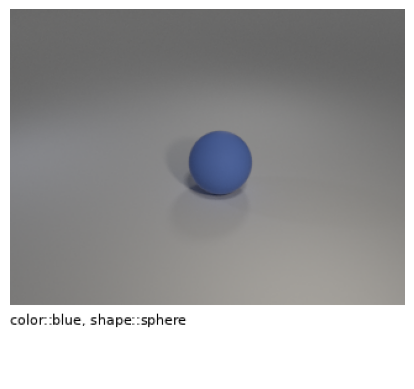

KeyError: 'color::blue'

In [21]:
img_idx = 1
concept = 'color::blue'
heatmap_type = 'avg_sim'
patch_size = (16, 16)
stride_ratio = 1
batch_size=1

print("Chosen data sample:")
plot_image_with_attributes(img_idx, dataset_name='CLEVR', save_image=True)

save_file = f'img_{img_idx}_heatmaptype_{heatmap_type.replace("_", "")}_model_CLIP_striderat_{stride_ratio}_patchsize_{patch_size[0]}{patch_size[1]}_{CONCEPTS_FILE[:-3]}'
heatmap = deletion_test(img_idx, concept, MODEL, PROCESSOR, DEVICE, concepts=concepts,
                        embeds_dic=embeds_dic, stride_ratio=stride_ratio, patch_size=patch_size,
                        heatmap_type=heatmap_type, batch_size=batch_size, save_file=save_file)
plot_heatmap(img_idx, heatmap, concept, heatmap_type=heatmap_type, save_file=save_file)

# Deletion Test on Given Image and all Concepts

In [49]:
def deletion_test_all_concepts(img_idx, patch_size=(16, 16), stride_ratio=0.5, heatmap_type="change_sim",
                               dataset_name='CLEVR', batch_size=64, save_file=None, concepts=None,
                               embeds_dic=None):
    """
    Generates heatmaps for all concepts in the dataset metadata for a given image.

    Args:
        img_idx (int): Index of the image in the metadata to analyze.
        patch_size (tuple): Size of patches to apply during the deletion test (default is (16, 16)).
        stride_ratio (float): Stride ratio for sliding patches during the deletion test (default is 0.5).
        heatmap_type (str): Type of heatmap to generate ('change_sim' or 'avg_sim', default is "change_sim").
        dataset_name (str): Name of the dataset (default is 'CLEVR').
        save_file (str): Where to save the heatmap tensor.

    Returns:
        dict: A dictionary where keys are concept names and values are the corresponding heatmaps.
    """
    concept_names = list(concepts.keys())[:5]
    concept_names.append('sheep')
    concept_names.append('car')
    
    heatmaps_dic = {}
    for concept in concept_names:
        heatmap = deletion_test(img_idx, concept, MODEL, PROCESSOR, DEVICE, concepts=concepts,
                                embeds_dic=embeds_dic, patch_size=patch_size, stride_ratio=stride_ratio,
                                heatmap_type=heatmap_type, dataset_name=dataset_name, batch_size=batch_size,
                                save_file=save_file)
                                
        heatmaps_dic[concept] = heatmap
        
    # ### match to gt concepts if it's unsupervised concepts
    # if concepts_file.startswith('CCE'):
    #     cos_sims = pd.read_csv(f'Cosine_Similarities/{dataset_name}/cosine_similarities_{concepts_file[:-3]}.csv')
    #     alignment_results, _ = find_closest_to_gt(concepts, cos_sims, dataset_name, PERCENT_THRU_MODEL, 'cls')
    #     filtered_heatmaps_dic = {}
    #     for gt_key, (concept_label, _, _) in alignment_results.items():
    #         filtered_heatmaps_dic[f'Concept {concept_label} (closest to {gt_key})'] = heatmaps_dic[concept_label]
    #     return filtered_heatmaps_dic
                  
    return heatmaps_dic

Chosen data sample:


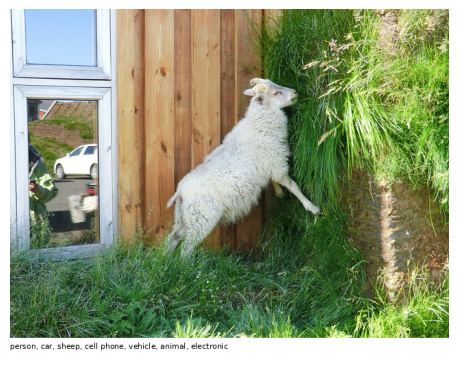

Original cosine similarity w concept car: 0.05064707249403


/shared_data0/cgoldberg/Concept_Inversion/Experiments/utils/deletion_test_utils.py:262: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for the color bar


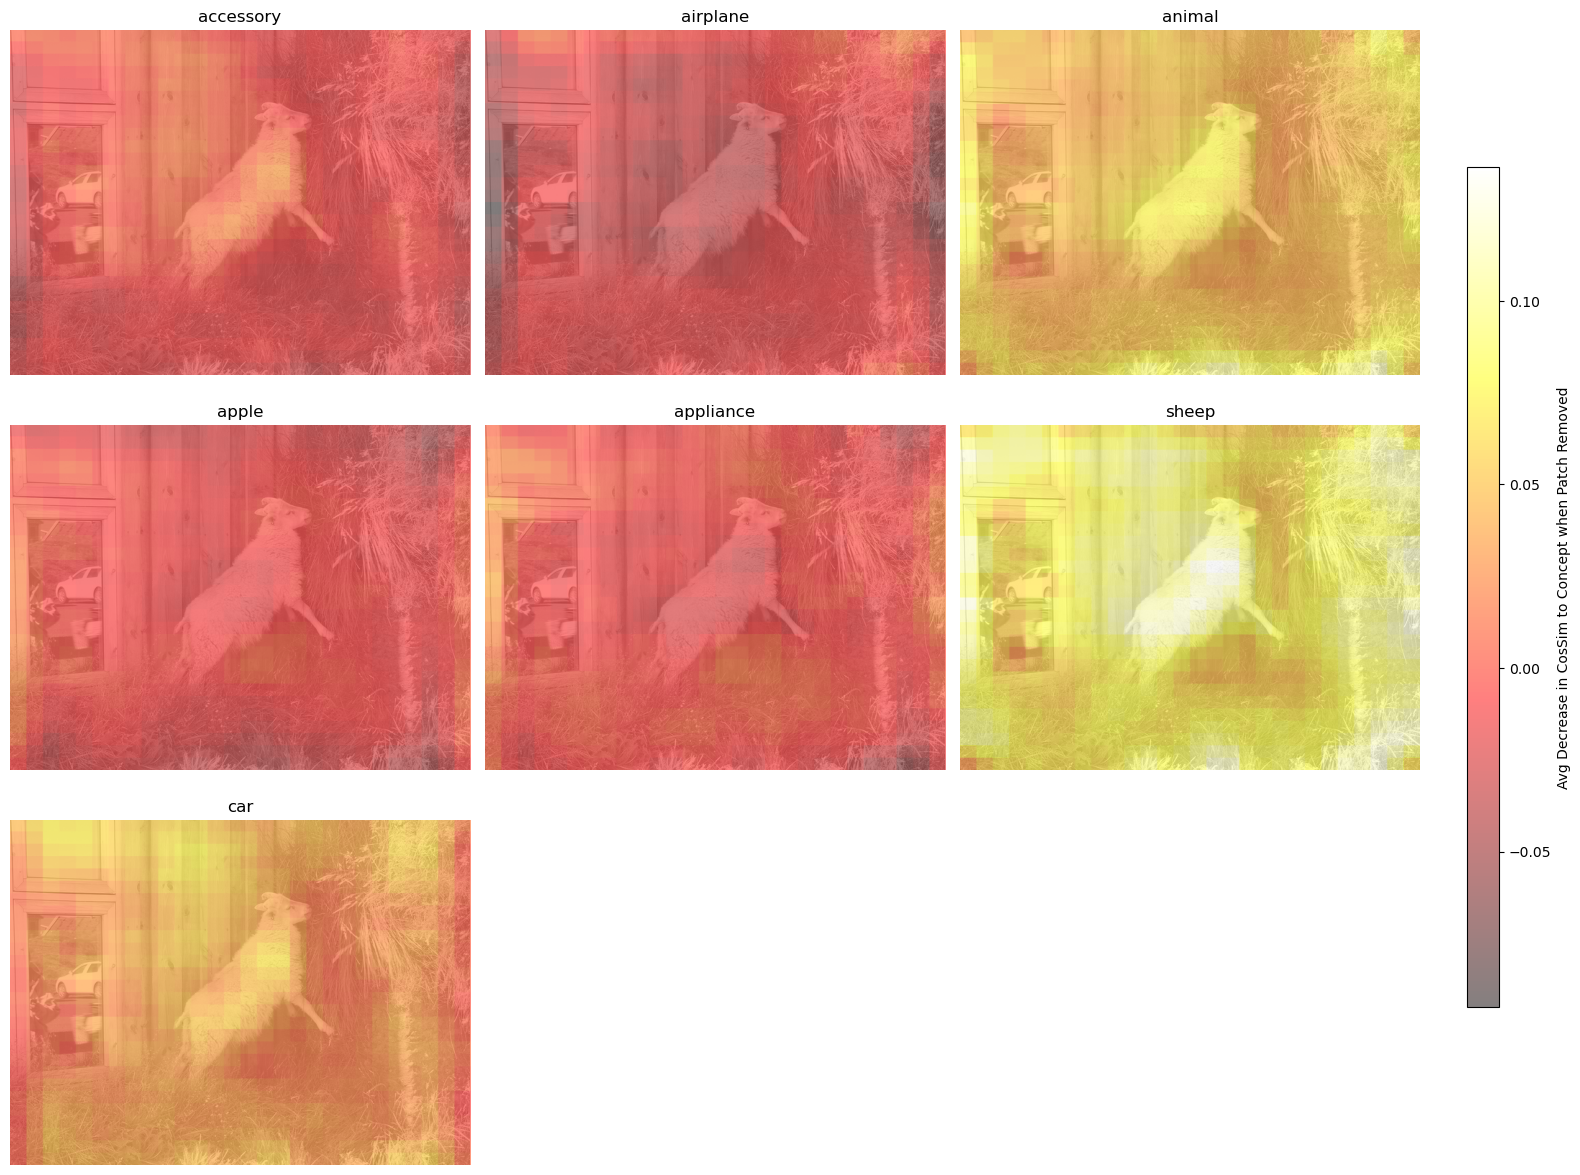

In [50]:
img_idx = 400
heatmap_type = 'change_sim'
patch_size = (16, 16)
stride_ratio = 0.5
batch_size = 8

save_file = f'img_{img_idx}_heatmaptype_{heatmap_type.replace("_", "")}_model_CLIP_striderat_{stride_ratio}_patchsize_{patch_size[0]}{patch_size[1]}_{CONCEPTS_FILE[:-3]}'

print("Chosen data sample:")
plot_image_with_attributes(img_idx, dataset_name=DATASET_NAME, save_image=True)

heatmaps_dic = deletion_test_all_concepts(img_idx, heatmap_type=heatmap_type, patch_size=patch_size, 
                                          stride_ratio=stride_ratio, batch_size=batch_size, 
                                          concepts=concepts, embeds_dic=embeds_dic,
                                          save_file=save_file, dataset_name=DATASET_NAME)
plot_heatmaps_all_concepts(img_idx, heatmaps_dic, heatmap_type=heatmap_type, save_file=save_file, dataset_name=DATASET_NAME)

# Quantitative Analysis

# Deletion Test for multiple images for each concept

In [ ]:
top_k=7
heatmap_type = 'change_sim'
metric_type = 'Change in Distance to Decision Boundary'
image_indices = retrieve_topn_images(DATASET_NAME, top_k, start_idx=4, split='test')
patch_size = (16, 16)
stride_ratio = 0.5
batch_size = 8

curr_min, curr_max = np.inf, -np.inf
for concept in concepts.keys():
    heatmaps = {}
    for img_idx in image_indices:
        save_file = f'img_{img_idx}_heatmaptype_{heatmap_type.replace("_", "")}_model_CLIP_striderat_{stride_ratio}_patchsize_{patch_size[0]}{patch_size[1]}_{CONCEPTS_FILE[:-3]}'
        heatmap = deletion_test(img_idx, concept, MODEL, PROCESSOR, DEVICE, concepts=concepts,
                                embeds_dic=embeds_dic, patch_size=(16, 16), stride_ratio=0.5,
                                    heatmap_type=heatmap_type, dataset_name='CLEVR',
                                    save_file=save_file)
        heatmaps[img_idx] = heatmap
        if heatmap.max() > curr_max:
            curr_max = heatmap.max()
        if heatmap.min() < curr_min:
            curr_min = heatmap.min()
    
    plot_patchsims_for_concept(concept, heatmaps, image_indices, all_images,
                               model_input_size=(224, 224), dataset_name='CLEVR', top_n=top_k, save_file=save_file,
                               metric_type = 'Distance to Decision Boundary', vmin=None, vmax=None)

# Deletion Test for Patch Embeddings

In [ ]:
def patch_deletion_test(img_idx, concept_key, model, processor, device, patch_size=(14, 14), stride_ratio=0.5, 
                  concepts_file=None, heatmap_type='change_sim', dataset_name='CLEVR', save_file=None):
    """
    Performs a deletion test on an image, blacking out patches and computing their importance for a given concept.

    Args:
        img_idx (int): Index of the image to be tested.
        concept_key (str): Key for the concept whose importance is being evaluated.
        model: The model to extract image embeddings.
        processor: The image processor used to prepare the image for the model.
        device: The device to run the model on.
        patch_size (tuple): Size of each patch as (height, width). Default is (16, 16).
        stride_ratio (float): Overlap ratio between patches. Default is 0.5.
        dataset_name (str): The name of the dataset being used.
        save_file (str): Where to save the heatmap tensor.

    Returns:
        Tensor: Heatmap of importance scores.
    """
    if save_file:
        save_path = f'Heatmaps/{dataset_name}/deltest_concept_{concept_key}_{save_file}.pt'
        
        #just return heatmap if you already ran this test
        if os.path.exists(save_path):
            return torch.load(save_path)
    
    #get the image at the index
    image = retrieve_image(img_idx, dataset_name)
    
    #create a list of tensors where various patches are blacked out
    imgs_w_blackedout_patches, patch_coords = blackout_patches(image, patch_size, stride_ratio)
    
    # Retrieve concept vector corresponding to given concept key and dataset
    concept_vector = torch.load(f'Concepts/{dataset_name}/{concepts_file}')[concept_key].to(device)
    
    # Retrieve original embedding for a given image and the cosine similarity with the concept vector
    original_embed = get_patch_embeddings(model, processor, image, device, PERCENT_THRU_MODEL)
    original_sim = F.cosine_similarity(original_embed.to(device), concept_vector.unsqueeze(0).to(device))
    avg_original_sim = torch.mean(original_sim)
    print(f"Original cosine similarity (average across patches) w concept {concept_key} is {avg_original_sim.item()}")
    
    # Get embeddings for images with blacked-out patches
    patched_embeds = get_patch_embeddings(model, processor, imgs_w_blackedout_patches, device, PERCENT_THRU_MODEL).to(device)
    
    # Compute similarity to chosen concept of blacked-out images
    blacked_patch_sims = F.cosine_similarity(patched_embeds, concept_vector.repeat(patched_embeds.shape[0], 1))
    reshaped_blacked_patch_sims = blacked_patch_sims.view(len(imgs_w_blackedout_patches), -1)
    avg_blacked_patch_sims = reshaped_blacked_patch_sims.mean(dim=1)
    
    # Compute the importance scores and generate the heatmap using the helper function
    if heatmap_type == 'change_sim':
        heatmap = compute_change_in_sim_heatmap(avg_original_sim, avg_blacked_patch_sims, patch_coords, image.size)
    elif heatmap_type == 'avg_sim':
        heatmap = compute_avg_similarity_heatmap(avg_original_sim, avg_blacked_patch_sims, patch_coords, image.size)
    
    if save_file:
        torch.save(heatmap, save_path)
        
    return heatmap

## Using GT Patch Concepts

In [ ]:
top_k=7
plot_type = 'change_sim'
image_indices = [i for i in range(top_k)]
concepts_file = f'avg_concepts_CLIP_patch_embeddings_percentthrumodel_{PERCENT_THRU_MODEL}.pt'

curr_min, curr_max = np.inf, -np.inf
for concept in concepts.keys():
    heatmaps = {}
    for img_idx in image_indices:
        
        save_file = f'patchdeltest_img_{img_idx}_heatmaptype_{plot_type.replace("_", "")}_model_CLIP_striderat_0.5_patchsize_1616'
        heatmap = patch_deletion_test(img_idx, concept, MODEL, PROCESSOR, DEVICE, concepts_file=concepts_file,
                                    patch_size=(16, 16), stride_ratio=0.5,
                                    heatmap_type=plot_type, dataset_name='CLEVR',
                                    save_file=save_file)
        heatmaps[img_idx] = heatmap
        if heatmap.max() > curr_max:
            curr_max = heatmap.max()
        if heatmap.min() < curr_min:
            curr_min = heatmap.min()
    
    plot_patchsims_for_concept(concept, image_indices, heatmaps, images,
                               model_input_size=images[0].size, dataset_name='CLEVR', save_file=None,
                              vmin=None, vmax=None)

## Using Unsupervised Patch Concepts Closest to GT

In [ ]:
top_k=7
plot_type = 'change_sim'
image_indices = [i for i in range(top_k)]
unsupervised_concepts_file = f'kmeans_1000_concepts_CLIP_patch_embeddings_percentthrumodel_70.pt'

unsupervised_patch_concepts = torch.load(f'Concepts/CLEVR/{unsupervised_concepts_file}')
gt_patch_concepts = torch.load(f'Concepts/CLEVR/avg_concepts_CLIP_patch_embeddings_percentthrumodel_{PERCENT_THRU_MODEL}.pt')

# Find the most aligned concept
alignment_results = {}
for gt_key, gt_embedding in gt_patch_concepts.items():
    max_similarity = float('-inf')
    best_match = None
    
    for unsupervised_key, unsupervised_embedding in unsupervised_patch_concepts.items():
        # Compute cosine similarity using PyTorch's cosine_similarity
        similarity = F.cosine_similarity(gt_embedding.unsqueeze(0), unsupervised_embedding.unsqueeze(0)).item()
        
        if similarity > max_similarity:
            max_similarity = similarity
            best_match = unsupervised_key
    
    alignment_results[gt_key] = (best_match, gt_embedding, max_similarity)

#Plot results
curr_min, curr_max = np.inf, -np.inf
for gt_key, (best_match_concept, embedding, similarity) in alignment_results.items():
    print(f"GT Concept {gt_key} aligns best with Unsupervised Concept {best_match_concept} (Similarity: {similarity:.4f})")
    heatmaps = {}
    for img_idx in image_indices:
        
        save_file = f'patchdeltest_unsupervised_img_{img_idx}_heatmaptype_{plot_type.replace("_", "")}_model_CLIP_striderat_0.5_patchsize_1616'
        heatmap = patch_deletion_test(img_idx, best_match_concept, MODEL, PROCESSOR, DEVICE, concepts_file=unsupervised_concepts_file,
                                    patch_size=(16, 16), stride_ratio=0.5,
                                    heatmap_type=plot_type, dataset_name='CLEVR',
                                    save_file=save_file)
        heatmaps[img_idx] = heatmap
        if heatmap.max() > curr_max:
            curr_max = heatmap.max()
        if heatmap.min() < curr_min:
            curr_min = heatmap.min()
    
    plot_patchsims_for_concept(best_match_concept, image_indices, heatmaps, images,
                               model_input_size=images[0].size, dataset_name='CLEVR', save_file=None,
                              vmin=None, vmax=None)